In [2]:
import pandas as pd
import numpy as np

# ============================================================
# FILE PATHS
# ============================================================

stock_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stocks_historical_clean.parquet"

macro_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\micro_indicators_monthly_clean.parquet"

output_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stock_macro_monthly_model.parquet"


# ============================================================
# 1. LOAD CLEAN DATA
# ============================================================

stocks = pd.read_parquet(stock_path)
macro = pd.read_parquet(macro_path)

print("=" * 70)
print("DATA LOADED")
print("=" * 70)

print("Stock shape:", stocks.shape)
print("Macro shape:", macro.shape)

print("\nStock date range:")
print(stocks["Date"].min(), "→", stocks["Date"].max())

print("\nMacro date range:")
print(macro["date"].min(), "→", macro["date"].max())


# ============================================================
# 2. PREPARE STOCK DATA
# ============================================================

stocks["Date"] = pd.to_datetime(stocks["Date"], errors="coerce")

stocks = stocks.sort_values(
    ["isin", "Date"]
).reset_index(drop=True)

# Create month
stocks["month"] = stocks["Date"].dt.to_period("M")


# ============================================================
# 3. DAILY → MONTHLY STOCK DATA
# ============================================================

monthly = (
    stocks
    .groupby(["isin", "symbol", "month"], as_index=False)
    .agg(
        monthly_open=("Open", "first"),
        monthly_high=("High", "max"),
        monthly_low=("Low", "min"),
        monthly_close=("Close", "last"),
        monthly_adj_close=("Adj Close", "last"),
        monthly_volume=("Volume", "sum"),
        trading_days=("Date", "count")
    )
)


# ============================================================
# 4. CONVERT MONTH → TIMESTAMP
# ============================================================

monthly["date"] = monthly["month"].dt.to_timestamp()

monthly = monthly.drop(columns=["month"])


# ============================================================
# 5. CALCULATE MONTHLY STOCK RETURN
# ============================================================

monthly = monthly.sort_values(
    ["isin", "date"]
).reset_index(drop=True)

monthly["stock_return_1m"] = (
    monthly
    .groupby("isin")["monthly_adj_close"]
    .pct_change() * 100
)


# ============================================================
# 6. CHECK MONTHLY STOCK DATA
# ============================================================

print("\n" + "=" * 70)
print("MONTHLY STOCK DATA")
print("=" * 70)

print("Shape:", monthly.shape)

print(
    "Date range:",
    monthly["date"].min(),
    "→",
    monthly["date"].max()
)

print("Unique ISINs:", monthly["isin"].nunique())

print(
    "Duplicate ISIN + date:",
    monthly.duplicated(["isin", "date"]).sum()
)

print("\nMissing values:")
print(monthly.isna().sum())


# ============================================================
# 7. PREPARE MACRO DATA
# ============================================================

macro["date"] = pd.to_datetime(
    macro["date"],
    errors="coerce"
)

macro = macro.sort_values("date").reset_index(drop=True)


# ============================================================
# 8. RESTRICT STOCK DATA TO MACRO PERIOD
# ============================================================

model_data = monthly[
    (monthly["date"] >= macro["date"].min()) &
    (monthly["date"] <= macro["date"].max())
].copy()


# ============================================================
# 9. MERGE MACRO DATA
# ============================================================

model_data = model_data.merge(
    macro,
    on="date",
    how="left"
)

model_data = model_data.sort_values(
    ["isin", "date"]
).reset_index(drop=True)


# ============================================================
# 10. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODELING DATASET")
print("=" * 70)

print("Shape:", model_data.shape)

print(
    "Date range:",
    model_data["date"].min(),
    "→",
    model_data["date"].max()
)

print("Unique ISINs:", model_data["isin"].nunique())

print(
    "Duplicate ISIN + date:",
    model_data.duplicated(["isin", "date"]).sum()
)

print("\nColumns:")
print(model_data.columns.tolist())


# ============================================================
# 11. MACRO MISSING VALUES
# ============================================================

macro_columns = [
    "oil_price_usd_bbl",
    "gold_price_inr_10g",
    "cpi_index",
    "cpi_inflation_yoy_pct",
    "oil_return_1m_pct",
    "oil_return_12m_pct",
    "gold_return_1m_pct",
    "gold_return_12m_pct",
    "inflation_change_1m",
    "house_price_index",
    "hpi_growth_12m_pct"
]

print("\nMacro missing values:")
print(model_data[macro_columns].isna().sum())


# ============================================================
# 12. STOCK HISTORY
# ============================================================

history = (
    model_data
    .groupby(["isin", "symbol"])
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        observations=("date", "count")
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("STOCK HISTORY")
print("=" * 70)

print(history["observations"].describe())

print(
    "\nStocks with >= 60 observations:",
    (history["observations"] >= 60).sum()
)

print(
    "Stocks with >= 120 observations:",
    (history["observations"] >= 120).sum()
)

print(
    "Stocks with >= 180 observations:",
    (history["observations"] >= 180).sum()
)


# ============================================================
# 13. SAVE
# ============================================================

model_data.to_parquet(
    output_path,
    index=False
)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(output_path)
print("Final shape:", model_data.shape)

DATA LOADED
Stock shape: (1677800, 14)
Macro shape: (201, 12)

Stock date range:
1991-01-02 00:00:00 → 2026-09-18 00:00:00

Macro date range:
2010-01-01 00:00:00 → 2026-09-01 00:00:00

MONTHLY STOCK DATA
Shape: (81344, 11)
Date range: 1991-01-01 00:00:00 → 2026-09-01 00:00:00
Unique ISINs: 437
Duplicate ISIN + date: 0

Missing values:
isin                   0
symbol                 0
monthly_open           0
monthly_high           0
monthly_low            0
monthly_close          0
monthly_adj_close      0
monthly_volume         0
trading_days           0
date                   0
stock_return_1m      437
dtype: int64

FINAL MODELING DATASET
Shape: (60846, 22)
Date range: 2010-01-01 00:00:00 → 2026-09-01 00:00:00
Unique ISINs: 437
Duplicate ISIN + date: 0

Columns:
['isin', 'symbol', 'monthly_open', 'monthly_high', 'monthly_low', 'monthly_close', 'monthly_adj_close', 'monthly_volume', 'trading_days', 'date', 'stock_return_1m', 'oil_price_usd_bbl', 'gold_price_inr_10g', 'cpi_index', 'cpi

In [3]:
import pandas as pd

# ============================================================
# LOAD MODELING DATA
# ============================================================

model_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stock_macro_monthly_model.parquet"

df = pd.read_parquet(model_path)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(
    ["isin", "date"]
).reset_index(drop=True)


# ============================================================
# CREATE NEXT-MONTH RETURN TARGET
# ============================================================

df["target_return_1m"] = (
    df.groupby("isin")["stock_return_1m"]
      .shift(-1)
)


# ============================================================
# VALIDATION
# ============================================================

print("=" * 70)
print("TARGET CREATION")
print("=" * 70)

print("Shape:", df.shape)

print("\nTarget missing values:")
print(df["target_return_1m"].isna().sum())

print("\nTarget statistics:")
print(df["target_return_1m"].describe())


# ============================================================
# CHECK ONE STOCK
# ============================================================

example = df[df["symbol"] == "RELIANCE"][
    [
        "date",
        "symbol",
        "stock_return_1m",
        "target_return_1m"
    ]
].head(15)

print("\nRELIANCE EXAMPLE:")
display(example)


# ============================================================
# SAVE
# ============================================================

target_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stock_macro_monthly_target.parquet"

df.to_parquet(
    target_path,
    index=False
)

print("\nSaved:")
print(target_path)

TARGET CREATION
Shape: (60846, 23)

Target missing values:
437

Target statistics:
count    60409.000000
mean         1.788788
std         11.206155
min        -82.461538
25%         -4.705887
50%          0.924257
75%          7.349875
max        350.303410
Name: target_return_1m, dtype: float64

RELIANCE EXAMPLE:


,date,symbol,stock_return_1m,target_return_1m
0,2010-01-01,RELIANCE,-4.066738,-6.428039
1,2010-02-01,RELIANCE,-6.428039,9.734929
2,2010-03-01,RELIANCE,9.734929,-3.784027
3,2010-04-01,RELIANCE,-3.784027,1.909299
4,2010-05-01,RELIANCE,1.909299,4.232022
5,2010-06-01,RELIANCE,4.232022,-7.358813
6,2010-07-01,RELIANCE,-7.358813,-8.958548
7,2010-08-01,RELIANCE,-8.958548,7.403199
8,2010-09-01,RELIANCE,7.403199,11.040734
9,2010-10-01,RELIANCE,11.040734,-10.093487



Saved:
C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stock_macro_monthly_target.parquet


RELIANCE SARIMA DATA
Shape: (201, 2)
Date range: 2010-01-01 00:00:00 → 2026-09-01 00:00:00

Missing returns:
0

Statistics:
count    201.000000
mean       1.130846
std        7.546621
min      -16.174308
25%       -3.965592
50%        0.501030
75%        5.799943
max       31.627385
Name: stock_return_1m, dtype: float64

First 10:


,symbol,stock_return_1m
date,,
2010-01-01,RELIANCE,-4.066738
2010-02-01,RELIANCE,-6.428039
2010-03-01,RELIANCE,9.734929
2010-04-01,RELIANCE,-3.784027
2010-05-01,RELIANCE,1.909299
2010-06-01,RELIANCE,4.232022
2010-07-01,RELIANCE,-7.358813
2010-08-01,RELIANCE,-8.958548
2010-09-01,RELIANCE,7.403199


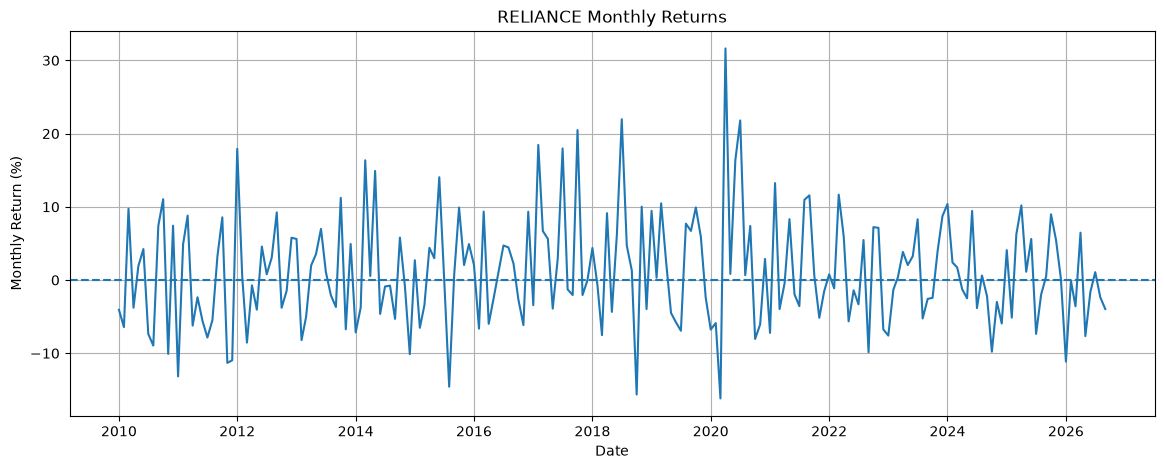

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD TARGET DATA
# ============================================================

target_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stock_macro_monthly_target.parquet"

df = pd.read_parquet(target_path)

df["date"] = pd.to_datetime(df["date"])


# ============================================================
# SELECT RELIANCE
# ============================================================

reliance = (
    df[df["symbol"] == "RELIANCE"]
    [
        [
            "date",
            "symbol",
            "stock_return_1m"
        ]
    ]
    .copy()
)

reliance = reliance.sort_values("date").reset_index(drop=True)


# ============================================================
# REMOVE FIRST MISSING RETURN
# ============================================================

reliance = reliance.dropna(
    subset=["stock_return_1m"]
).copy()


# ============================================================
# SET DATE INDEX
# ============================================================

reliance = reliance.set_index("date")

reliance = reliance.asfreq("MS")


# ============================================================
# CHECK
# ============================================================

print("=" * 70)
print("RELIANCE SARIMA DATA")
print("=" * 70)

print("Shape:", reliance.shape)

print(
    "Date range:",
    reliance.index.min(),
    "→",
    reliance.index.max()
)

print("\nMissing returns:")
print(reliance["stock_return_1m"].isna().sum())

print("\nStatistics:")
print(reliance["stock_return_1m"].describe())

print("\nFirst 10:")
display(reliance.head(10))


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    reliance.index,
    reliance["stock_return_1m"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("RELIANCE Monthly Returns")
plt.xlabel("Date")
plt.ylabel("Monthly Return (%)")
plt.grid(True)

plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller

# ============================================================
# ADF STATIONARITY TEST
# ============================================================

series = reliance["stock_return_1m"]

result = adfuller(series)

print("=" * 70)
print("ADF STATIONARITY TEST — RELIANCE MONTHLY RETURNS")
print("=" * 70)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")


# ============================================================
# INTERPRETATION
# ============================================================

if result[1] < 0.05:
    print("\nRESULT: Stationary")
    print("Use d = 0")
else:
    print("\nRESULT: Non-stationary")
    print("Differencing may be required.")

ADF STATIONARITY TEST — RELIANCE MONTHLY RETURNS
ADF Statistic: -9.176284826668427
p-value: 2.315450826066223e-15

Critical Values:
1%: -3.463987334463603
5%: -2.8763259091636213
10%: -2.5746515171738515

RESULT: Stationary
Use d = 0


C:\Users\313635\AppData\Local\Temp\ipykernel_10436\899887007.py:9: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)


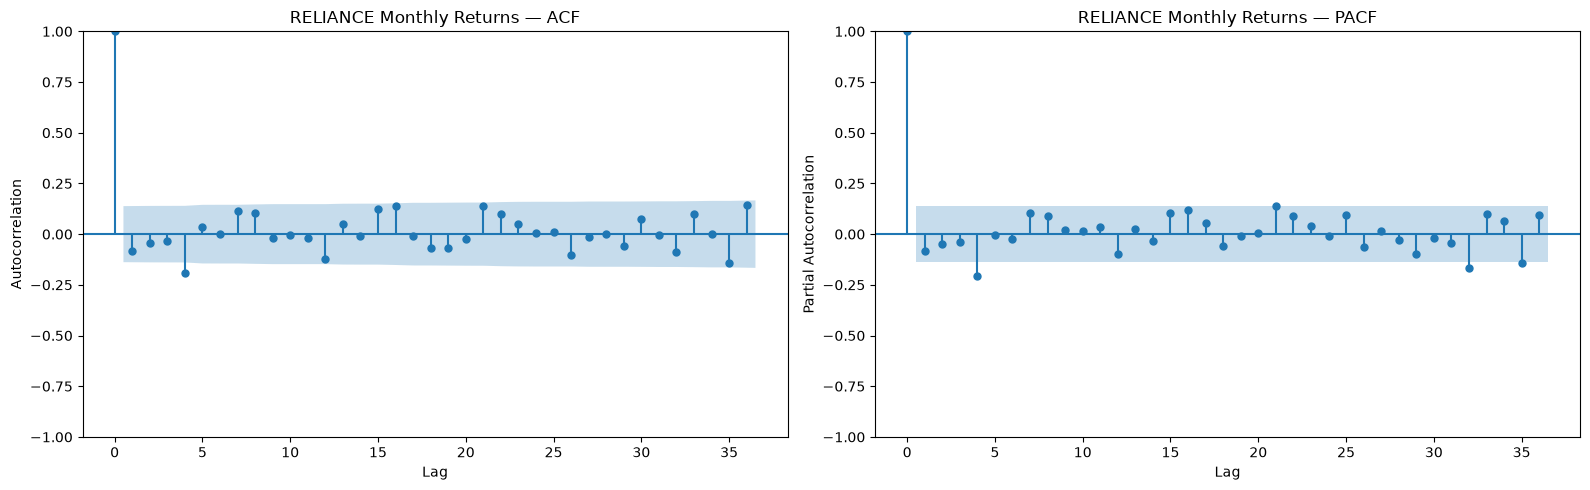

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ============================================================
# ACF + PACF
# ============================================================

series = reliance["stock_return_1m"]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# ACF
plot_acf(
    series,
    lags=36,
    ax=ax[0]
)

ax[0].set_title("RELIANCE Monthly Returns — ACF")
ax[0].set_xlabel("Lag")
ax[0].set_ylabel("Autocorrelation")

# PACF
plot_pacf(
    series,
    lags=36,
    ax=ax[1],
    method="ywm"
)

ax[1].set_title("RELIANCE Monthly Returns — PACF")
ax[1].set_xlabel("Lag")
ax[1].set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

In [9]:
import warnings
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

series = reliance["stock_return_1m"].copy()

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

# Last 24 months = test set
test_size = 24

train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

print("=" * 70)
print("SARIMA TRAIN / TEST SPLIT")
print("=" * 70)

print("Total observations:", len(series))
print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTrain:")
print(train.index.min(), "→", train.index.max())

print("\nTest:")
print(test.index.min(), "→", test.index.max())


# ============================================================
# CANDIDATE SARIMA MODELS
# ============================================================

candidates = []

# Non-seasonal models
for p in range(0, 3):
    for q in range(0, 3):

        candidates.append({
            "order": (p, 0, q),
            "seasonal_order": (0, 0, 0, 0)
        })


# Seasonal candidates
# Keep these deliberately small.
for p in range(0, 2):
    for q in range(0, 2):

        candidates.append({
            "order": (p, 0, q),
            "seasonal_order": (0, 0, 1, 12)
        })

        candidates.append({
            "order": (p, 0, q),
            "seasonal_order": (1, 0, 0, 12)
        })


# ============================================================
# FIT MODELS
# ============================================================

results = []

print("\n" + "=" * 70)
print("FITTING CANDIDATE MODELS")
print("=" * 70)

for candidate in candidates:

    order = candidate["order"]
    seasonal_order = candidate["seasonal_order"]

    try:

        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(
            disp=False
        )

        results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        print(
            f"SARIMA{order}x{seasonal_order} "
            f"→ AIC={fitted.aic:.2f}, BIC={fitted.bic:.2f}"
        )

    except Exception as e:

        print(
            f"FAILED: SARIMA{order}x{seasonal_order}"
        )


# ============================================================
# RESULTS
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "AIC"
).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODELS SORTED BY AIC")
print("=" * 70)

display(results_df)

SARIMA TRAIN / TEST SPLIT
Total observations: 201
Training observations: 177
Testing observations: 24

Train:
2010-01-01 00:00:00 → 2024-09-01 00:00:00

Test:
2024-10-01 00:00:00 → 2026-09-01 00:00:00

FITTING CANDIDATE MODELS
SARIMA(0, 0, 0)x(0, 0, 0, 0) → AIC=1223.06, BIC=1229.40
SARIMA(0, 0, 1)x(0, 0, 0, 0) → AIC=1216.15, BIC=1225.65
SARIMA(0, 0, 2)x(0, 0, 0, 0) → AIC=1209.65, BIC=1222.29
SARIMA(1, 0, 0)x(0, 0, 0, 0) → AIC=1223.33, BIC=1232.84
SARIMA(1, 0, 1)x(0, 0, 0, 0) → AIC=1216.49, BIC=1229.15
SARIMA(1, 0, 2)x(0, 0, 0, 0) → AIC=1211.46, BIC=1227.25
SARIMA(2, 0, 0)x(0, 0, 0, 0) → AIC=1217.32, BIC=1229.97
SARIMA(2, 0, 1)x(0, 0, 0, 0) → AIC=1218.19, BIC=1234.02
SARIMA(2, 0, 2)x(0, 0, 0, 0) → AIC=1211.76, BIC=1230.72
SARIMA(0, 0, 0)x(0, 0, 1, 12) → AIC=1135.01, BIC=1144.31
SARIMA(0, 0, 0)x(1, 0, 0, 12) → AIC=1145.85, BIC=1155.16
SARIMA(0, 0, 1)x(0, 0, 1, 12) → AIC=1129.92, BIC=1142.30
SARIMA(0, 0, 1)x(1, 0, 0, 12) → AIC=1146.80, BIC=1159.22
SARIMA(1, 0, 0)x(0, 0, 1, 12) → AIC=1136.

,order,seasonal_order,AIC,BIC
0,"(0, 0, 1)","(0, 0, 1, 12)",1129.922706,1142.297707
1,"(1, 0, 1)","(0, 0, 1, 12)",1130.481790,1145.950541
2,"(0, 0, 0)","(0, 0, 1, 12)",1135.013671,1144.313271
3,"(1, 0, 0)","(0, 0, 1, 12)",1136.037788,1148.437254
4,"(1, 0, 0)","(1, 0, 0, 12)",1136.965476,1149.364942
5,"(1, 0, 1)","(1, 0, 0, 12)",1138.917893,1154.417226
6,"(0, 0, 0)","(1, 0, 0, 12)",1145.846915,1155.164752
7,"(0, 0, 1)","(1, 0, 0, 12)",1146.795608,1159.219390
8,"(0, 0, 2)","(0, 0, 0, 0)",1209.652879,1222.289100
9,"(1, 0, 2)","(0, 0, 0, 0)",1211.455872,1227.251148


In [11]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# TRAIN / TEST DATA
# ============================================================

series = reliance["stock_return_1m"].copy()

test_size = 24

train = series.iloc[:-test_size]
test = series.iloc[-test_size:]


# ============================================================
# MODELS TO EVALUATE
# ============================================================

candidate_models = [
    ((0, 0, 1), (0, 0, 1, 12)),
    ((1, 0, 1), (0, 0, 1, 12)),
    ((0, 0, 0), (0, 0, 1, 12)),
    ((1, 0, 0), (0, 0, 1, 12)),
    ((1, 0, 0), (1, 0, 0, 12)),
    ((1, 0, 1), (1, 0, 0, 12)),
    ((0, 0, 0), (1, 0, 0, 12)),
    ((0, 0, 1), (1, 0, 0, 12)),
    ((0, 0, 2), (0, 0, 0, 0))
]


# ============================================================
# EVALUATION
# ============================================================

evaluation_results = []

print("=" * 70)
print("OUT-OF-SAMPLE SARIMA EVALUATION")
print("=" * 70)

for order, seasonal_order in candidate_models:

    try:

        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        # Forecast exactly 24 unseen months
        forecast = fitted.forecast(
            steps=len(test)
        )

        # Align indexes
        forecast = pd.Series(
            forecast,
            index=test.index
        )

        # Metrics
        mae = mean_absolute_error(
            test,
            forecast
        )

        rmse = np.sqrt(
            mean_squared_error(
                test,
                forecast
            )
        )

        evaluation_results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "MAE": mae,
            "RMSE": rmse
        })

        print(
            f"SARIMA{order}x{seasonal_order} "
            f"→ MAE={mae:.4f}, RMSE={rmse:.4f}"
        )

    except Exception as e:

        print(
            f"FAILED {order} x {seasonal_order}: {e}"
        )


# ============================================================
# RESULTS
# ============================================================

evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df = evaluation_df.sort_values(
    "RMSE"
).reset_index(drop=True)

print("\n" + "=" * 70)
print("FINAL OUT-OF-SAMPLE RANKING")
print("=" * 70)

display(evaluation_df)

OUT-OF-SAMPLE SARIMA EVALUATION
SARIMA(0, 0, 1)x(0, 0, 1, 12) → MAE=5.3038, RMSE=6.2133
SARIMA(1, 0, 1)x(0, 0, 1, 12) → MAE=5.3579, RMSE=6.2752
SARIMA(0, 0, 0)x(0, 0, 1, 12) → MAE=5.2929, RMSE=6.1835
SARIMA(1, 0, 0)x(0, 0, 1, 12) → MAE=5.3065, RMSE=6.2126
SARIMA(1, 0, 0)x(1, 0, 0, 12) → MAE=5.2747, RMSE=6.1995
SARIMA(1, 0, 1)x(1, 0, 0, 12) → MAE=5.2811, RMSE=6.2072
SARIMA(0, 0, 0)x(1, 0, 0, 12) → MAE=5.2210, RMSE=6.1408
SARIMA(0, 0, 1)x(1, 0, 0, 12) → MAE=5.2403, RMSE=6.1751
SARIMA(0, 0, 2)x(0, 0, 0, 0) → MAE=5.1182, RMSE=6.0993

FINAL OUT-OF-SAMPLE RANKING


,order,seasonal_order,AIC,BIC,MAE,RMSE
0,"(0, 0, 2)","(0, 0, 0, 0)",1209.652879,1222.289100,5.118237,6.099346
1,"(0, 0, 0)","(1, 0, 0, 12)",1145.846915,1155.164752,5.221026,6.140813
2,"(0, 0, 1)","(1, 0, 0, 12)",1146.795608,1159.219390,5.240309,6.175053
3,"(0, 0, 0)","(0, 0, 1, 12)",1135.013671,1144.313271,5.292897,6.183466
4,"(1, 0, 0)","(1, 0, 0, 12)",1136.965476,1149.364942,5.274661,6.199467
5,"(1, 0, 1)","(1, 0, 0, 12)",1138.917893,1154.417226,5.281124,6.207172
6,"(1, 0, 0)","(0, 0, 1, 12)",1136.037788,1148.437254,5.306530,6.212621
7,"(0, 0, 1)","(0, 0, 1, 12)",1129.922706,1142.297707,5.303801,6.213274
8,"(1, 0, 1)","(0, 0, 1, 12)",1130.481790,1145.950541,5.357876,6.275169


In [12]:
# ============================================================
# ZERO-RETURN BASELINE
# ============================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

zero_forecast = np.zeros(len(test))

baseline_mae = mean_absolute_error(
    test,
    zero_forecast
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test,
        zero_forecast
    )
)

print("=" * 70)
print("ZERO-RETURN BASELINE")
print("=" * 70)

print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")


# ============================================================
# COMPARE WITH ARIMA(0,0,2)
# ============================================================

arima_002 = evaluation_df[
    (evaluation_df["order"] == (0, 0, 2)) &
    (evaluation_df["seasonal_order"] == (0, 0, 0, 0))
].iloc[0]

print("\n" + "=" * 70)
print("ARIMA(0,0,2) vs ZERO BASELINE")
print("=" * 70)

print(f"ARIMA MAE  : {arima_002['MAE']:.4f}")
print(f"Baseline MAE: {baseline_mae:.4f}")

print(f"\nARIMA RMSE  : {arima_002['RMSE']:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")

ZERO-RETURN BASELINE
MAE  : 4.7311
RMSE : 5.7369

ARIMA(0,0,2) vs ZERO BASELINE
ARIMA MAE  : 5.1182
Baseline MAE: 4.7311

ARIMA RMSE  : 6.0993
Baseline RMSE: 5.7369


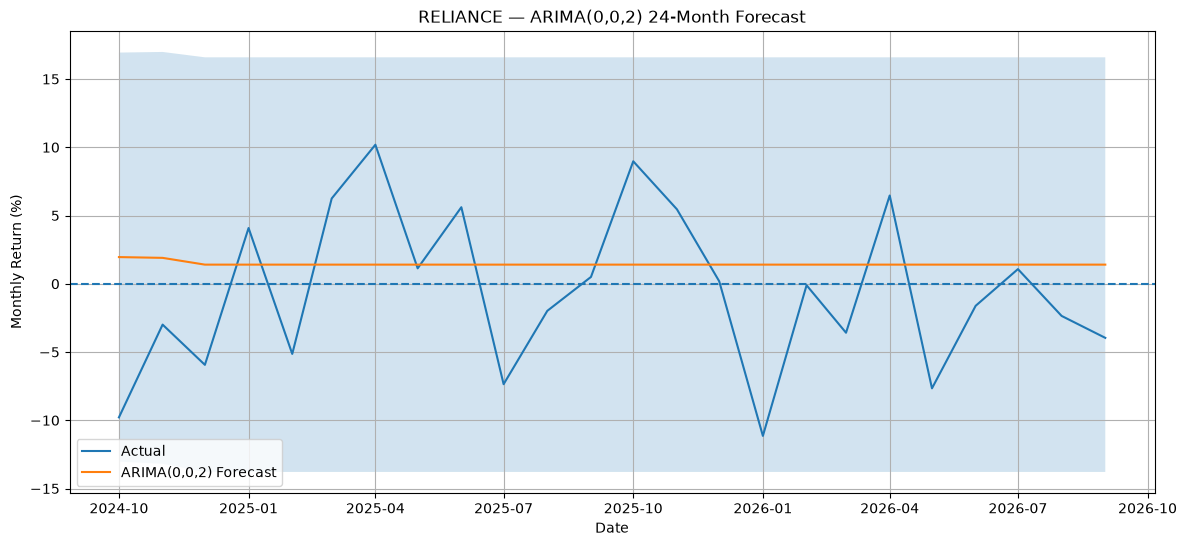

In [13]:
# ============================================================
# FIT ARIMA(0,0,2) AND FORECAST
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

model = SARIMAX(
    train,
    order=(0, 0, 2),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

fitted = model.fit(disp=False)

forecast = fitted.get_forecast(
    steps=len(test)
)

predicted = forecast.predicted_mean
confidence = forecast.conf_int()

predicted.index = test.index
confidence.index = test.index


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    predicted.index,
    predicted,
    label="ARIMA(0,0,2) Forecast"
)

plt.fill_between(
    confidence.index,
    confidence.iloc[:, 0],
    confidence.iloc[:, 1],
    alpha=0.2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("RELIANCE — ARIMA(0,0,2) 24-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Monthly Return (%)")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD MODELING DATA
# ============================================================

model_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stock_macro_monthly_target.parquet"

df = pd.read_parquet(model_path)

df["date"] = pd.to_datetime(df["date"])

# ============================================================
# SELECT RELIANCE
# ============================================================

reliance_sarimax = (
    df[df["symbol"] == "RELIANCE"]
    .copy()
)

reliance_sarimax = reliance_sarimax.sort_values(
    "date"
).reset_index(drop=True)


# ============================================================
# FEATURES
# ============================================================

exog_columns = [
    "oil_price_usd_bbl",
    "gold_price_inr_10g",
    "cpi_inflation_yoy_pct"
]


# ============================================================
# CHECK MISSING VALUES
# ============================================================

print("=" * 70)
print("SARIMAX EXOGENOUS VARIABLES")
print("=" * 70)

print("Date range:")
print(
    reliance_sarimax["date"].min(),
    "→",
    reliance_sarimax["date"].max()
)

print("\nMissing values:")
print(
    reliance_sarimax[
        exog_columns + ["stock_return_1m"]
    ].isna().sum()
)


# ============================================================
# CREATE TIME SERIES
# ============================================================

reliance_sarimax = reliance_sarimax.set_index(
    "date"
).asfreq("MS")


y = reliance_sarimax["stock_return_1m"]

X = reliance_sarimax[exog_columns]


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

test_size = 24

y_train = y.iloc[:-test_size]
y_test = y.iloc[-test_size:]

X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]


# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("SARIMAX TRAIN / TEST")
print("=" * 70)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining period:")
print(
    y_train.index.min(),
    "→",
    y_train.index.max()
)

print("\nTesting period:")
print(
    y_test.index.min(),
    "→",
    y_test.index.max()
)

print("\nTraining X missing:")
print(X_train.isna().sum())

print("\nTesting X missing:")
print(X_test.isna().sum())

SARIMAX EXOGENOUS VARIABLES
Date range:
2010-01-01 00:00:00 → 2026-09-01 00:00:00

Missing values:
oil_price_usd_bbl         0
gold_price_inr_10g        0
cpi_inflation_yoy_pct    49
stock_return_1m           0
dtype: int64

SARIMAX TRAIN / TEST
y_train: (177,)
y_test : (24,)
X_train: (177, 3)
X_test : (24, 3)

Training period:
2010-01-01 00:00:00 → 2024-09-01 00:00:00

Testing period:
2024-10-01 00:00:00 → 2026-09-01 00:00:00

Training X missing:
oil_price_usd_bbl         0
gold_price_inr_10g        0
cpi_inflation_yoy_pct    48
dtype: int64

Testing X missing:
oil_price_usd_bbl        0
gold_price_inr_10g       0
cpi_inflation_yoy_pct    1
dtype: int64


In [2]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD DATA
# ============================================================

model_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stock_macro_monthly_target.parquet"

df = pd.read_parquet(model_path)

df["date"] = pd.to_datetime(df["date"])


# ============================================================
# SELECT RELIANCE
# ============================================================

reliance = (
    df[df["symbol"] == "RELIANCE"]
    .sort_values("date")
    .copy()
)


# ============================================================
# SET MONTHLY INDEX
# ============================================================

reliance = (
    reliance
    .set_index("date")
    .asfreq("MS")
)


# ============================================================
# TARGET
# ============================================================

# target_return_1m = next month's return

y = reliance["target_return_1m"]


# ============================================================
# EXOGENOUS VARIABLES
# ============================================================

exog_columns = [
    "oil_price_usd_bbl",
    "gold_price_inr_10g"
]

X = reliance[exog_columns]


# ============================================================
# REMOVE LAST ROW
# ============================================================

# Last month has no future return,
# therefore it cannot be used as a target.

valid = y.notna()

y = y[valid]
X = X.loc[y.index]


# ============================================================
# CHECK
# ============================================================

print("=" * 70)
print("RELIANCE SARIMAX DATA")
print("=" * 70)

print("Target:", "next month's return")

print("\nShape:")
print("y:", y.shape)
print("X:", X.shape)

print("\nDate range:")
print(y.index.min(), "→", y.index.max())

print("\nMissing target:")
print(y.isna().sum())

print("\nMissing X:")
print(X.isna().sum())


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

test_size = 24

y_train = y.iloc[:-test_size]
y_test = y.iloc[-test_size:]

X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]


# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("SARIMAX TRAIN / TEST")
print("=" * 70)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining period:")
print(y_train.index.min(), "→", y_train.index.max())

print("\nTesting period:")
print(y_test.index.min(), "→", y_test.index.max())

print("\nTraining X missing:")
print(X_train.isna().sum())

print("\nTesting X missing:")
print(X_test.isna().sum())

RELIANCE SARIMAX DATA
Target: next month's return

Shape:
y: (200,)
X: (200, 2)

Date range:
2010-01-01 00:00:00 → 2026-08-01 00:00:00

Missing target:
0

Missing X:
oil_price_usd_bbl     0
gold_price_inr_10g    0
dtype: int64

SARIMAX TRAIN / TEST
y_train: (176,)
y_test : (24,)
X_train: (176, 2)
X_test : (24, 2)

Training period:
2010-01-01 00:00:00 → 2024-08-01 00:00:00

Testing period:
2024-09-01 00:00:00 → 2026-08-01 00:00:00

Training X missing:
oil_price_usd_bbl     0
gold_price_inr_10g    0
dtype: int64

Testing X missing:
oil_price_usd_bbl     0
gold_price_inr_10g    0
dtype: int64


In [1]:
import warnings
import pandas as pd
import numpy as np

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")


# ============================================================
# LOAD DATA
# ============================================================

model_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stock_macro_monthly_target.parquet"

df = pd.read_parquet(model_path)

df["date"] = pd.to_datetime(df["date"])


# ============================================================
# SELECT RELIANCE
# ============================================================

reliance = (
    df[df["symbol"] == "RELIANCE"]
    .sort_values("date")
    .copy()
)

reliance = (
    reliance
    .set_index("date")
    .asfreq("MS")
)


# ============================================================
# TARGET
# ============================================================

y = reliance["target_return_1m"]


# ============================================================
# EXOGENOUS VARIABLES
# ============================================================

exog_columns = [
    "oil_price_usd_bbl",
    "gold_price_inr_10g"
]

X = reliance[exog_columns]


# ============================================================
# REMOVE LAST ROW
# ============================================================

valid = y.notna()

y = y[valid]
X = X.loc[y.index]


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

test_size = 24

y_train = y.iloc[:-test_size]
y_test = y.iloc[-test_size:]

X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]


print("=" * 70)
print("SARIMAX DATA")
print("=" * 70)

print("Total observations:", len(y))

print("Training observations:", len(y_train))
print("Testing observations:", len(y_test))

print("\nTraining period:")
print(y_train.index.min(), "→", y_train.index.max())

print("\nTesting period:")
print(y_test.index.min(), "→", y_test.index.max())

print("\nMissing X_train:")
print(X_train.isna().sum())

print("\nMissing X_test:")
print(X_test.isna().sum())


# ============================================================
# SARIMAX CANDIDATES
# ============================================================

candidate_models = [

    # Non-seasonal
    ((0, 0, 0), (0, 0, 0, 0)),
    ((0, 0, 1), (0, 0, 0, 0)),
    ((0, 0, 2), (0, 0, 0, 0)),
    ((1, 0, 0), (0, 0, 0, 0)),
    ((1, 0, 1), (0, 0, 0, 0)),
    ((2, 0, 0), (0, 0, 0, 0)),
    ((2, 0, 1), (0, 0, 0, 0)),

    # Seasonal AR
    ((0, 0, 0), (1, 0, 0, 12)),
    ((0, 0, 1), (1, 0, 0, 12)),
    ((1, 0, 0), (1, 0, 0, 12)),
    ((1, 0, 1), (1, 0, 0, 12)),

    # Seasonal MA
    ((0, 0, 0), (0, 0, 1, 12)),
    ((0, 0, 1), (0, 0, 1, 12)),
    ((1, 0, 0), (0, 0, 1, 12)),
    ((1, 0, 1), (0, 0, 1, 12)),
]


# ============================================================
# FIT + FORECAST
# ============================================================

results = []

print("\n" + "=" * 70)
print("SARIMAX OUT-OF-SAMPLE EVALUATION")
print("=" * 70)

for order, seasonal_order in candidate_models:

    try:

        model = SARIMAX(
            y_train,
            exog=X_train,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(
            disp=False
        )

        # Forecast the 24 unseen months
        forecast = fitted.get_forecast(
            steps=len(y_test),
            exog=X_test
        )

        predicted = forecast.predicted_mean

        # Align index
        predicted.index = y_test.index

        # Metrics
        mae = mean_absolute_error(
            y_test,
            predicted
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predicted
            )
        )

        results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "MAE": mae,
            "RMSE": rmse
        })

        print(
            f"SARIMAX{order}x{seasonal_order}"
            f" → MAE={mae:.4f}, RMSE={rmse:.4f}"
        )

    except Exception as e:

        print(
            f"FAILED {order} x {seasonal_order}: {e}"
        )


# ============================================================
# RESULTS TABLE
# ============================================================

sarimax_results = pd.DataFrame(results)

sarimax_results = sarimax_results.sort_values(
    "RMSE"
).reset_index(drop=True)


print("\n" + "=" * 70)
print("SARIMAX RESULTS — SORTED BY RMSE")
print("=" * 70)

display(sarimax_results)

SARIMAX DATA
Total observations: 200
Training observations: 176
Testing observations: 24

Training period:
2010-01-01 00:00:00 → 2024-08-01 00:00:00

Testing period:
2024-09-01 00:00:00 → 2026-08-01 00:00:00

Missing X_train:
oil_price_usd_bbl     0
gold_price_inr_10g    0
dtype: int64

Missing X_test:
oil_price_usd_bbl     0
gold_price_inr_10g    0
dtype: int64

SARIMAX OUT-OF-SAMPLE EVALUATION
SARIMAX(0, 0, 0)x(0, 0, 0, 0) → MAE=8.1433, RMSE=9.6364
SARIMAX(0, 0, 1)x(0, 0, 0, 0) → MAE=7.6763, RMSE=9.1425
SARIMAX(0, 0, 2)x(0, 0, 0, 0) → MAE=7.6681, RMSE=9.1326
SARIMAX(1, 0, 0)x(0, 0, 0, 0) → MAE=7.7169, RMSE=9.1881
SARIMAX(1, 0, 1)x(0, 0, 0, 0) → MAE=7.2008, RMSE=8.6036
SARIMAX(2, 0, 0)x(0, 0, 0, 0) → MAE=7.7582, RMSE=9.2335
SARIMAX(2, 0, 1)x(0, 0, 0, 0) → MAE=7.3508, RMSE=8.7694
SARIMAX(0, 0, 0)x(1, 0, 0, 12) → MAE=8.3036, RMSE=9.8205
SARIMAX(0, 0, 1)x(1, 0, 0, 12) → MAE=8.3214, RMSE=9.8484
SARIMAX(1, 0, 0)x(1, 0, 0, 12) → MAE=8.2860, RMSE=9.8042
SARIMAX(1, 0, 1)x(1, 0, 0, 12) → MAE=7

,order,seasonal_order,AIC,BIC,MAE,RMSE
0,"(1, 0, 1)","(0, 0, 0, 0)",1210.133297,1229.087628,7.200757,8.603557
1,"(2, 0, 1)","(0, 0, 0, 0)",1212.070689,1234.184077,7.350777,8.769413
2,"(1, 0, 1)","(0, 0, 1, 12)",1126.107569,1147.720743,7.514350,8.878397
3,"(1, 0, 1)","(1, 0, 0, 12)",1132.914476,1154.570727,7.538104,8.911626
4,"(0, 0, 2)","(0, 0, 0, 0)",1204.328482,1223.248231,7.668053,9.132642
5,"(0, 0, 1)","(0, 0, 0, 0)",1210.708400,1226.503676,7.676323,9.142547
6,"(1, 0, 0)","(0, 0, 0, 0)",1218.239347,1234.063277,7.716894,9.188077
7,"(2, 0, 0)","(0, 0, 0, 0)",1211.928588,1230.882920,7.758198,9.233505
8,"(0, 0, 1)","(0, 0, 1, 12)",1126.097201,1144.622779,7.907955,9.322071
9,"(0, 0, 0)","(0, 0, 0, 0)",1218.446438,1231.105582,8.143327,9.636425
